Creating probabilty density functions for zonal and meridial speeds

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.stats import norm 
import geopandas as gpd 
from functions import funcs 
import numpy as np 

In [2]:
ds = gpd.read_parquet("Data/Mapped_SAT_MI_Cleanedspeeds.parquet")

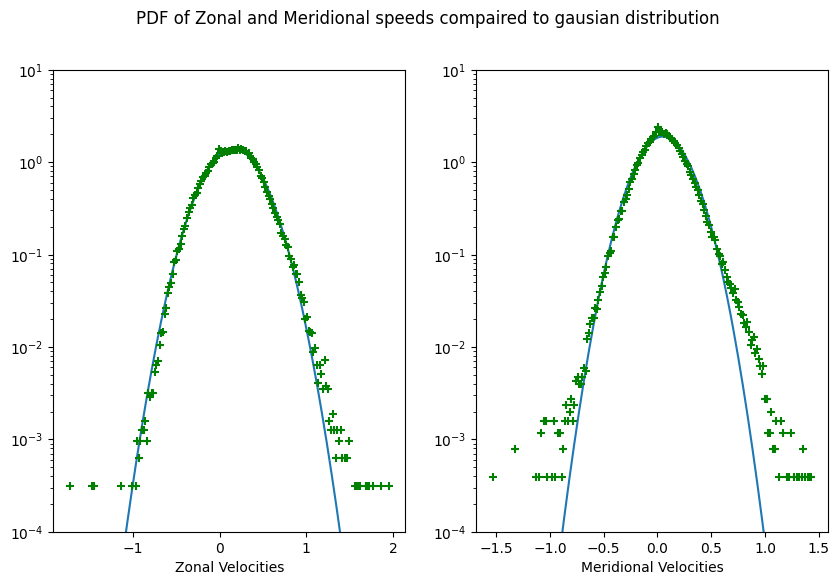

In [6]:
x_speeds = funcs.Column_to_List(ds, "x_speed")
y_speeds = funcs.Column_to_List(ds, "y_speed") 
xmean = np.mean(x_speeds)
ymean = np.mean(y_speeds)
xvar = np.var(x_speeds)
yvar = np.var(y_speeds)
xrange = np.linspace(min(x_speeds), max(x_speeds), 200)
yrange = np.linspace(min(y_speeds), max(y_speeds), 200)
pdfx = norm.pdf(xrange, loc = xmean, scale = np.sqrt(xvar))
pdfy = norm.pdf(yrange, loc = ymean, scale = np.sqrt(yvar))
fig, ax = plt.subplots(1,2, figsize = (10,6))
counts, bins, patches = ax[0].hist(x_speeds, density= True, bins = 200, histtype='step', color = "White")
bin_centers = (bins[:-1] + bins[1:]) / 2
ax[0].scatter(bin_centers, counts, marker='+', color='g', zorder=10)
ax[0].plot(xrange,pdfx)
ax[0].set_xlabel("Zonal Velocities")
ax[1].set_xlabel("Meridional Velocities")
#ax[1].hist(y_speeds, density= True, bins = 200)
counts, bins, patches = ax[1].hist(y_speeds, density= True, bins = 200, histtype='step', color = "White")
bin_centers = (bins[:-1] + bins[1:]) / 2
ax[1].scatter(bin_centers, counts, marker='+', color='g', zorder=10)
ax[1].plot(yrange,pdfy)
ax[1].set_yscale("log")
ax[0].set_yscale("log")
ax[1].set_ylim(10e-5, 10)
ax[0].set_ylim(10e-5, 10)
fig.suptitle("PDF of Zonal and Meridional speeds compaired to gausian distribution")
fig.savefig(r"../Figures/PDF_of_dFADs_speeds.png")
